# BirdCLEF+ 2026: Exploratory Data Analysis

This notebook provides an initial look at the competition data, focusing on species distribution, audio characteristics, and geographic metadata.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import IPython.display as ipd
from glob import glob

# Setup paths
DATA_DIR = '../data/raw'
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, 'train_audio')

sns.set(style="whitegrid")

## 1. Metadata Analysis
Load the `train.csv` file and examine the basic structure.

In [2]:
df = pd.read_csv(TRAIN_CSV)
print(f"Total training samples: {len(df)}")
df.head()

Total training samples: 35549


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


### Species Distribution
How many unique species are there? What is the distribution of samples per species?

Unique species (primary labels): 206


C:\Users\Manikandan\AppData\Local\Temp\ipykernel_18344\3580915254.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')


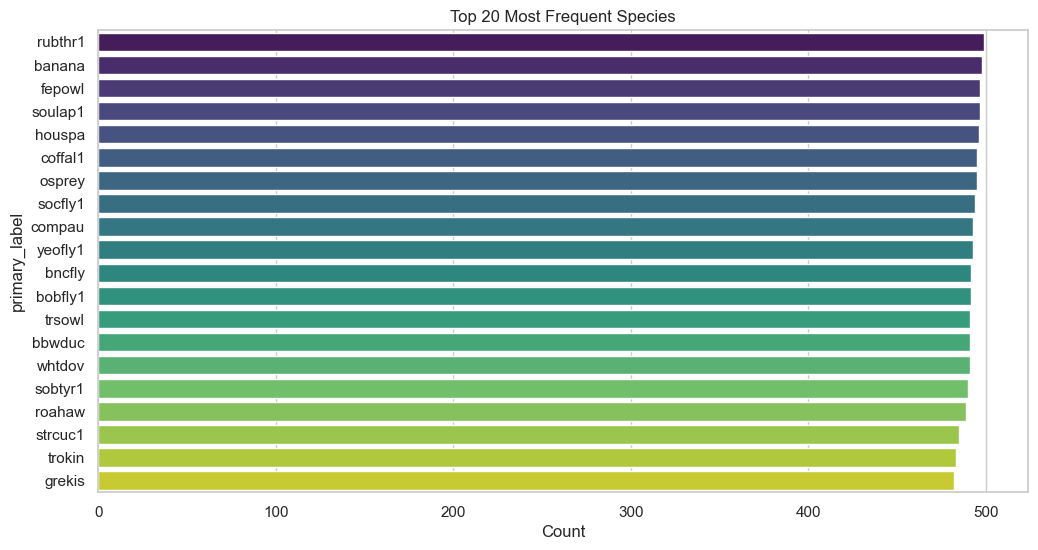

In [3]:
n_species = df['primary_label'].nunique()
print(f"Unique species (primary labels): {n_species}")

top_20 = df['primary_label'].value_counts().head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')
plt.title('Top 20 Most Frequent Species')
plt.xlabel('Count')
plt.show()

### Geographic Distribution
Where were these recordings collected? (Note: Pantanal wetlands)

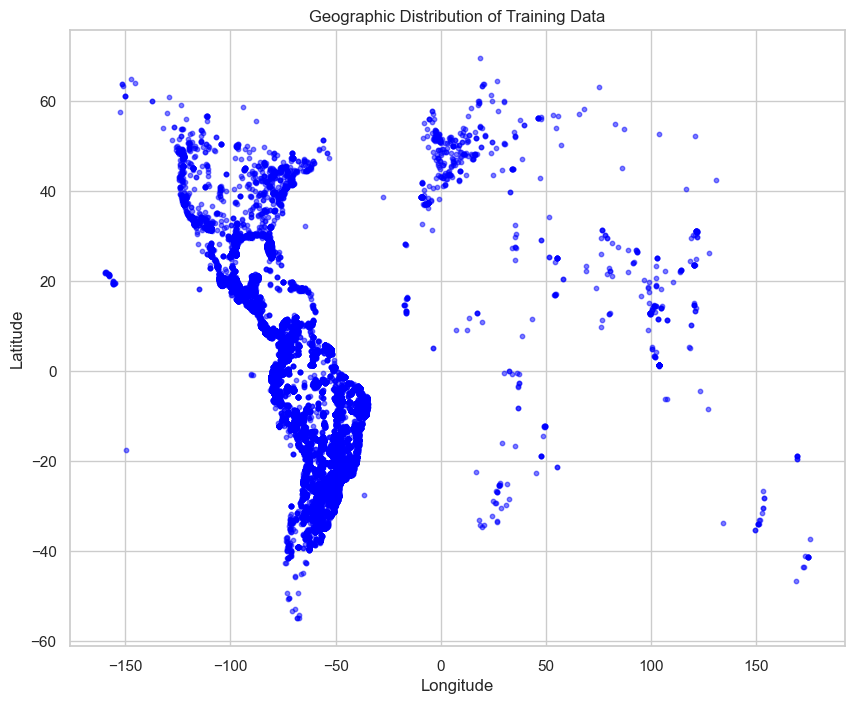

In [4]:
plt.figure(figsize=(10, 8))
plt.scatter(df['longitude'], df['latitude'], alpha=0.5, s=10, c='blue')
plt.title('Geographic Distribution of Training Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [5]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import soundfile as sf

def plot_audio(filename):
    path = os.path.join(TRAIN_AUDIO_DIR, filename)
    
    # --- Debug: Check file exists and size ---
    print(f"Full path: {path}")
    print(f"File exists: {os.path.exists(path)}")
    if os.path.exists(path):
        print(f"File size: {os.path.getsize(path)} bytes")
    
    # --- Fix 1: Try loading with soundfile first to detect format ---
    try:
        info = sf.info(path)
        print(f"Format: {info.format}, Subtype: {info.subtype}, Sample rate: {info.samplerate}")
    except Exception as e:
        print(f"Soundfile info error: {e}")
    
    # --- Fix 2: Use audioread backend explicitly for non-WAV files ---
    try:
        y, sr = librosa.load(path, sr=32000, res_type='kaiser_fast')
    except Exception:
        # --- Fix 3: Try loading as MP3/OGG regardless of extension ---
        try:
            import audioread
            with audioread.audio_open(path) as f:
                print(f"Audioread detected format, channels: {f.channels}, sr: {f.samplerate}")
            y, sr = librosa.load(path, sr=32000)
        except Exception as e2:
            print(f"All loading methods failed: {e2}")
            return None, None
    
    fig, ax = plt.subplots(2, 1, figsize=(15, 10))
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title(f'Waveform: {filename}')
    
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=16000, ax=ax[1])
    fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
    ax[1].set_title('Mel-spectrogram')
    
    plt.tight_layout()
    plt.show()
    return y, sr

In [7]:
import os

TRAIN_AUDIO_DIR = '../data/raw/train_audio'

print("Folder exists:", os.path.exists(TRAIN_AUDIO_DIR))
print("Files inside:", os.listdir(TRAIN_AUDIO_DIR) if os.path.exists(TRAIN_AUDIO_DIR) else "FOLDER MISSING")

Folder exists: True
Files inside: ['1161364', '116570', '1176823', '1595929', '209233', '22930', '22956', '22961', '22967', '22973', '22983', '22985', '23150', '23154', '23158', '23176', '23724', '24279', '24285', '24287', '24321', '244024', '25092', '25214', '326272', '41970', '43435', '47144', '476521', '516975', '555123', '555145', '555146', '64898', '65377', '65380', '66971', '67107', '67252', '70711', '738183', '74113', '74580', '760266', 'ashgre1', 'astcra1', 'bafcur1', 'baffal1', 'banana', 'barant1', 'batbel1', 'baymac', 'bbwduc', 'bcwfin2', 'bkcdon', 'bkhpar', 'blchaw1', 'blheag1', 'blttit1', 'bncfly', 'bobfly1', 'brcmar1', 'brnowl', 'bucmot4', 'bucpar', 'bufpar', 'bunibi1', 'burowl', 'camfli1', 'chacha1', 'chbmoc1', 'chobla1', 'chvcon1', 'cibspi1', 'coffal1', 'compau', 'compot1', 'crbthr1', 'crebec1', 'dwatin1', 'epaori4', 'eulfly1', 'fabwre1', 'fepowl', 'ficman1', 'file1.wav', 'file2.wav', 'file3.wav', 'file4.wav', 'file_0.wav', 'file_1.wav', 'file_10.wav', 'file_11.wav', 'fi

In [8]:
import os

TRAIN_AUDIO_DIR = '../data/raw/train_audio'

# Check inside one subfolder
sample_folder = os.path.join(TRAIN_AUDIO_DIR, 'ashgre1')
print(os.listdir(sample_folder)[:5])

['iNat1005716.ogg', 'iNat1400791.ogg', 'iNat222942.ogg', 'iNat344251.ogg', 'iNat398205.ogg']


In [11]:
import os
import pandas as pd
import glob

DATA_DIR = '../data/raw'
TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, 'train_audio')

# Check subfolders
subfolders = os.listdir(TRAIN_AUDIO_DIR)
print(f"Total subfolders: {len(subfolders)}")
print("Sample folders:", subfolders[:5])

# Check files inside one subfolder
sample_folder = os.path.join(TRAIN_AUDIO_DIR, subfolders[0])
print("\nFiles in first folder:", os.listdir(sample_folder)[:5])

Total subfolders: 230
Sample folders: ['1161364', '116570', '1176823', '1595929', '209233']

Files in first folder: ['iNat1114648.ogg', 'iNat1216197.ogg', 'iNat1264238.ogg', 'iNat547199.ogg', 'iNat556514.ogg']


In [12]:
df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
print(df.shape)
print(df.columns.tolist())
print(df['filename'].head(5))

(35549, 15)
['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']
0    1161364/iNat1216197.ogg
1    1161364/iNat1114648.ogg
2     1161364/iNat810195.ogg
3     1161364/iNat818781.ogg
4     1161364/iNat556514.ogg
Name: filename, dtype: object


In [13]:
# Build full filepath
df['filepath'] = df['filename'].apply(
    lambda x: os.path.join(TRAIN_AUDIO_DIR, x)
)

# Verify files exist
df['file_exists'] = df['filepath'].apply(os.path.exists)
print(f"Files found: {df['file_exists'].sum()} / {len(df)}")

# Plot a real file
all_ogg = glob.glob(os.path.join(TRAIN_AUDIO_DIR, '**', '*.ogg'), recursive=True)
print(f"\nTotal .ogg files: {len(all_ogg)}")
print("First file:", all_ogg[0])

Files found: 35549 / 35549

Total .ogg files: 35549
First file: ../data/raw\train_audio\1161364\iNat1114648.ogg


In [6]:
# Install: pip install pydub
from pydub import AudioSegment
import glob

for f in glob.glob(os.path.join(TRAIN_AUDIO_DIR, "*.wav")):
    try:
        audio = AudioSegment.from_file(f)  # auto-detects format
        audio.export(f, format="wav")      # re-saves as real WAV
        print(f"Converted: {f}")
    except Exception as e:
        print(f"Failed {f}: {e}")

Failed ../data/raw\train_audio\file1.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file2.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file3.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file4.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file_0.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file_1.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file_10.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file_11.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file_12.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\train_audio\file_13.wav: [WinError 2] The system cannot find the file specified
Failed ../data/raw\t

C:\Users\Manikandan\anaconda3\envs\gemini\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
C:\Users\Manikandan\anaconda3\envs\gemini\Lib\site-packages\pydub\utils.py:198: RuntimeWarning: Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work
  warn("Couldn't find ffprobe or avprobe - defaulting to ffprobe, but may not work", RuntimeWarning)


## 2. Audio Exploration
Let's listen to a random sample and visualize its waveform and spectrogram.

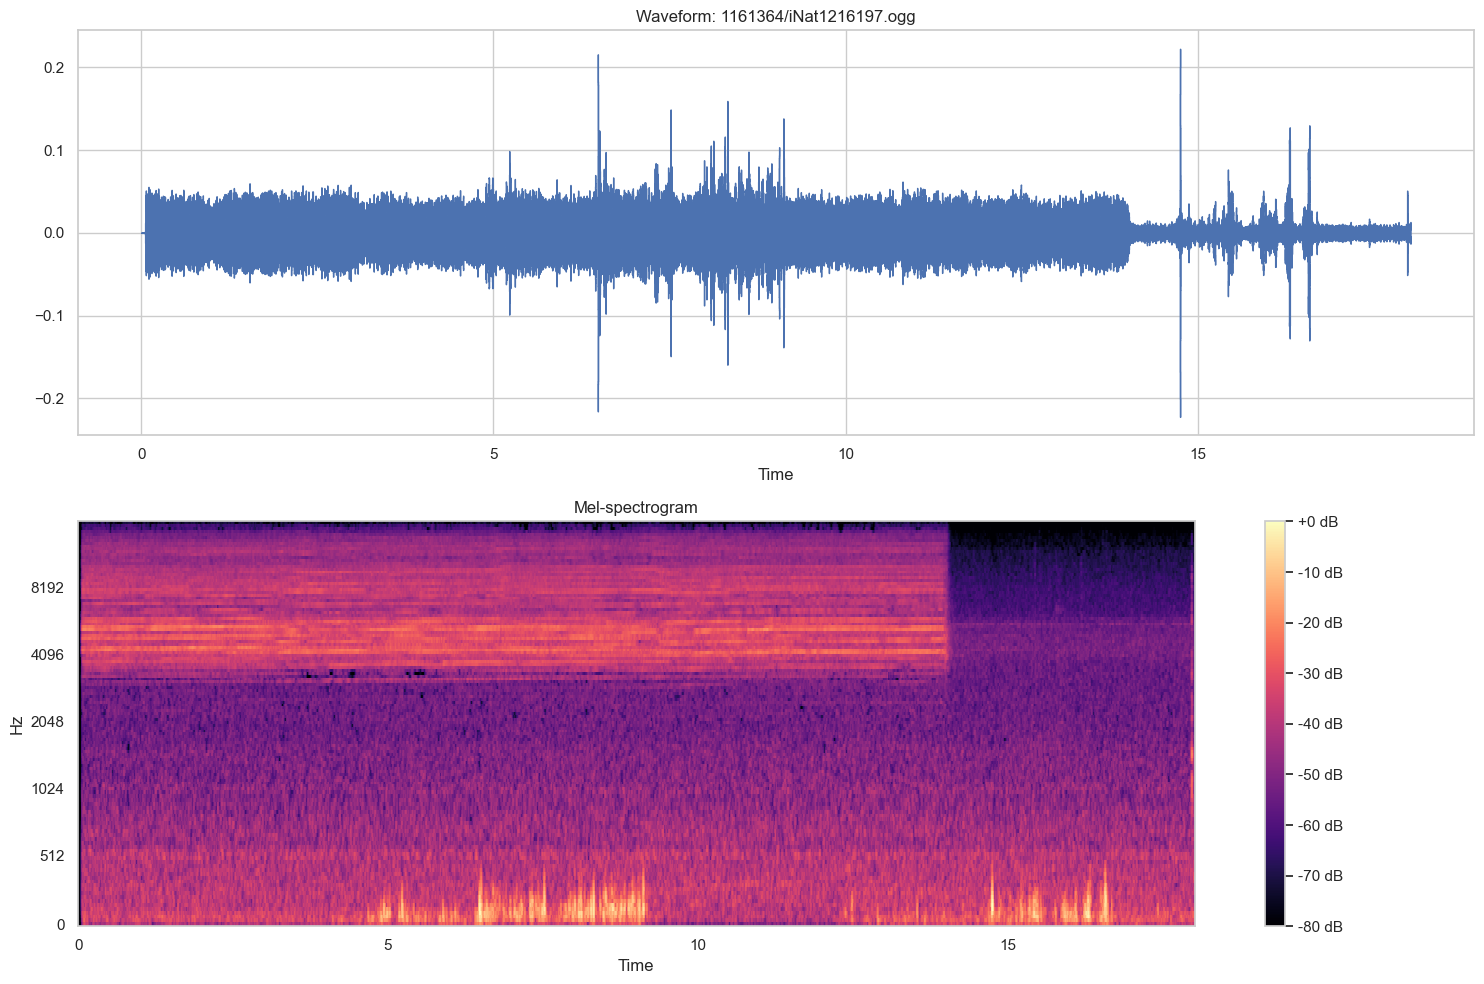

In [7]:
def plot_audio(filename):
    path = os.path.join(TRAIN_AUDIO_DIR, filename)
    y, sr = librosa.load(path, sr=32000)
    
    fig, ax = plt.subplots(2, 1, figsize=(15, 10))
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title(f'Waveform: {filename}')
    
    # Mel-spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=16000, ax=ax[1])
    fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
    ax[1].set_title('Mel-spectrogram')
    
    plt.tight_layout()
    plt.show()
    return y, sr

# Randomly select a file from the first 5 entries
sample_file = df.iloc[0]['filename']
y, sr = plot_audio(sample_file)
ipd.Audio(y, rate=sr)

## 3. Data Challenges
- **Imbalanced Classes**: Some species have many more recordings than others.
- **Background Noise**: Field recordings often contain wind, rain, and other background sounds.
- **Non-Bird Taxa**: Identification of amphibians, reptiles, mammals, and insects using iNaturalist taxon IDs.